
# Vector Operations — Plain Python Demo

This notebook gives hands-on demos of the vector concepts from the chapter:

- Column/row vectors (represented as Python lists)
- Dimensionality
- Dot product
- Vector addition & subtraction
- Element-wise (Hadamard) product
- Norm (length / magnitude)
- Unit vectors
- Cosine similarity and the angle between vectors
- Basic input validation / helpful error messages

**Design choices:** we avoid external libraries and use only Python built-ins and the `math` module.
Where we visualize in 2D, we use `matplotlib` (optional).


## Core helpers (plain Python)

In [1]:

from math import sqrt, acos, isclose

def _check_same_dim(a, b):
    if len(a) != len(b):
        raise ValueError(f"Vectors must have same dimensionality (got {len(a)} and {len(b)})")

def dimensionality(x):
    "Return the size (number of components) of vector x."
    return len(x)

def add(a, b):
    "Vector sum a + b."
    _check_same_dim(a, b)
    return [a[i] + b[i] for i in range(len(a))]

def subtract(a, b):
    "Vector difference a - b."
    _check_same_dim(a, b)
    return [a[i] - b[i] for i in range(len(a))]

def scalar_mul(c, x):
    "Scalar multiplication: c * x."
    return [c * xi for xi in x]

def hadamard(a, b):
    "Element-wise (Hadamard) product a o b."
    _check_same_dim(a, b)
    return [a[i] * b[i] for i in range(len(a))]

def dot(a, b):
    "Dot product a · b."
    _check_same_dim(a, b)
    s = 0.0
    for i in range(len(a)):
        s += a[i] * b[i]
    return s

def norm(x):
    "Euclidean norm ||x||."
    return sqrt(sum(xi * xi for xi in x))

def unit(x):
    "Return unit vector x_hat = x / ||x||. Raises if x is the zero vector."
    n = norm(x)
    if isclose(n, 0.0):
        raise ValueError("Cannot make a unit vector from the zero vector.")
    return [xi / n for xi in x]

def cosine_similarity(x, y):
    "cos(theta) = (x · y) / (||x|| ||y||)."
    _check_same_dim(x, y)
    nx, ny = norm(x), norm(y)
    if isclose(nx, 0.0) or isclose(ny, 0.0):
        raise ValueError("Cosine similarity undefined for zero vector(s).")
    return dot(x, y) / (nx * ny)

def angle_degrees(x, y):
    "Angle in degrees between vectors x and y (0–180)."
    from math import degrees
    c = cosine_similarity(x, y)
    # Numerical safety: clamp to [-1, 1]
    c = max(-1.0, min(1.0, c))
    return degrees(acos(c))


### Quick checks

In [2]:

# Basic unit-style tests to validate the functions
x = [3, 4]
y = [4, -3]

assert dimensionality(x) == 2
assert add([1,2,3], [4,5,6]) == [5,7,9]
assert subtract([5,7,9], [4,5,6]) == [1,2,3]
assert scalar_mul(2, [1,2,3]) == [2,4,6]
assert hadamard([1,2,3], [4,5,6]) == [4,10,18]
assert dot([1,2,3], [4,5,6]) == 32
assert isclose(norm([3,4]), 5.0)
ux = unit(x)
assert isclose(norm(ux), 1.0, rel_tol=1e-9)
cos_xy = cosine_similarity(x, y)
ang_xy = angle_degrees(x, y)
print("All checks passed.")
print(f"cos(x, y) = {cos_xy:.4f}, angle = {ang_xy:.2f} degrees")


All checks passed.
cos(x, y) = 0.0000, angle = 90.00 degrees


## Worked example in 2D

In [4]:

x = [1, 2, 3]
y = [1, 2, 3]

print("x =", x)
print("y =", y)
print("Dimensionality:", dimensionality(x))

print("\nAddition x + y:", add(x, y))
print("Subtraction x - y:", subtract(x, y))
print("Element-wise x o y:", hadamard(x, y))

print("\nDot product x · y:")
steps = [f"{x[i]}*{y[i]}" for i in range(len(x))]
print(" + ".join(steps), "=", dot(x, y))

print("\nNorms: ||x||, ||y||")
print(f"||x|| = sqrt({x[0]}^2 + {x[1]}^2) = {norm(x):.4f}")
print(f"||y|| = sqrt({y[0]}^2 + {y[1]}^2) = {norm(y):.4f}")

ux = unit(x)
uy = unit(y)
print("\nUnit vectors:")
print("x_hat =", [round(v, 4) for v in ux])
print("y_hat =", [round(v, 4) for v in uy])
print("||x_hat|| =", round(norm(ux), 6), ", ||y_hat|| =", round(norm(uy), 6))

cos_xy = cosine_similarity(x, y)
theta = angle_degrees(x, y)
print("\nCosine similarity and angle:")
print(f"cos(theta) = (x·y)/(||x||·||y||) = {cos_xy:.6f}")
print(f"theta = arccos(cos(theta)) ≈ {theta:.2f} degrees")


x = [1, 2, 3]
y = [1, 2, 3]
Dimensionality: 3

Addition x + y: [2, 4, 6]
Subtraction x - y: [0, 0, 0]
Element-wise x o y: [1, 4, 9]

Dot product x · y:
1*1 + 2*2 + 3*3 = 14.0

Norms: ||x||, ||y||
||x|| = sqrt(1^2 + 2^2) = 3.7417
||y|| = sqrt(1^2 + 2^2) = 3.7417

Unit vectors:
x_hat = [0.2673, 0.5345, 0.8018]
y_hat = [0.2673, 0.5345, 0.8018]
||x_hat|| = 1.0 , ||y_hat|| = 1.0

Cosine similarity and angle:
cos(theta) = (x·y)/(||x||·||y||) = 1.000000
theta = arccos(cos(theta)) ≈ 0.00 degrees


## Try your own vectors

In [5]:

# Edit these and re-run the cell
a = [1, 2, 3, 4]
b = [2, 1, 0, -1]

print("a + b =", add(a, b))
print("a - b =", subtract(a, b))
print("a o b =", hadamard(a, b))
print("a · b =", dot(a, b))
print("||a|| =", norm(a))
print("||b|| =", norm(b))
print("cos(a,b) =", cosine_similarity(a, b))
print("angle(a,b) =", angle_degrees(a, b), "degrees")
try:
    print("unit(a) =", unit(a))
except ValueError as e:
    print("Unit vector error:", e)


a + b = [3, 3, 3, 3]
a - b = [-1, 1, 3, 5]
a o b = [2, 2, 0, -4]
a · b = 0.0
||a|| = 5.477225575051661
||b|| = 2.449489742783178
cos(a,b) = 0.0
angle(a,b) = 90.0 degrees
unit(a) = [0.18257418583505536, 0.3651483716701107, 0.5477225575051661, 0.7302967433402214]



## (Optional) Visualize vectors and the angle in 2D

This section uses `matplotlib` to draw vectors and the angle between them.
If `matplotlib` is not available in your environment, you can skip this section.


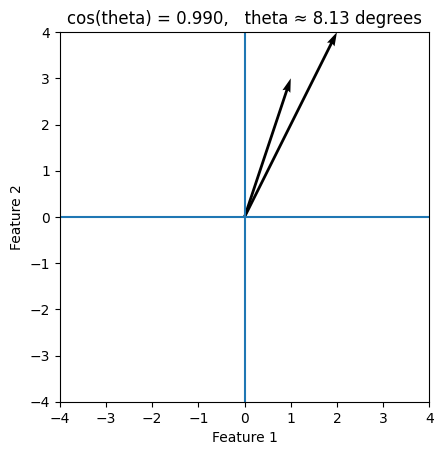

In [6]:

try:
    import matplotlib.pyplot as plt

    def plot_vectors(p, q):
        "Plot two 2D vectors and the angle between them."
        if len(p) != 2 or len(q) != 2:
            raise ValueError("This plotter expects 2D vectors.")

        xs = [0, p[0], q[0]]
        ys = [0, p[1], q[1]]
        lim = max(4, int(max(map(abs, xs + ys))))

        plt.figure()
        plt.axhline(0)
        plt.axvline(0)
        plt.quiver([0,0],[0,0],[p[0],q[0]],[p[1],q[1]], angles='xy', scale_units='xy', scale=1)

        c = cosine_similarity(p, q)
        theta = angle_degrees(p, q)
        plt.title(f"cos(theta) = {c:.3f},   theta ≈ {theta:.2f} degrees")

        plt.xlim(-lim, lim)
        plt.ylim(-lim, lim)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.show()

    # Example
    plot_vectors([2,4], [1,3])
except Exception as e:
    print("Plotting skipped or failed:", e)
